# Cybersecurity: Suspicious Web Threat Interactions

In [1]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

# Machine Learning (Sklearn)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Deep Learning (TensorFlow / Keras)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D, Flatten, Dropout
from tensorflow.keras.optimizers import Adam

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load the dataset
df = pd.read_csv('Downloads/CloudWatch_Traffic_Web_Attack.csv')

### Data Preprocessing

In [3]:
df.head(10)

,bytes_in,bytes_out,creation_time,end_time,src_ip,src_ip_country_code,protocol,response.code,dst_port,dst_ip,rule_names,observation_name,source.meta,source.name,time,detection_types
0,5602,12990,2024-04-25T23:00:00Z,2024-04-25T23:10:00Z,147.161.161.82,AE,HTTPS,200,443,10.138.69.97,Suspicious Web Traffic,Adversary Infrastructure Interaction,AWS_VPC_Flow,prod_webserver,2024-04-25T23:00:00Z,waf_rule
1,30912,18186,2024-04-25T23:00:00Z,2024-04-25T23:10:00Z,165.225.33.6,US,HTTPS,200,443,10.138.69.97,Suspicious Web Traffic,Adversary Infrastructure Interaction,AWS_VPC_Flow,prod_webserver,2024-04-25T23:00:00Z,waf_rule
2,28506,13468,2024-04-25T23:00:00Z,2024-04-25T23:10:00Z,165.225.212.255,CA,HTTPS,200,443,10.138.69.97,Suspicious Web Traffic,Adversary Infrastructure Interaction,AWS_VPC_Flow,prod_webserver,2024-04-25T23:00:00Z,waf_rule
3,30546,14278,2024-04-25T23:00:00Z,2024-04-25T23:10:00Z,136.226.64.114,US,HTTPS,200,443,10.138.69.97,Suspicious Web Traffic,Adversary Infrastructure Interaction,AWS_VPC_Flow,prod_webserver,2024-04-25T23:00:00Z,waf_rule
4,6526,13892,2024-04-25T23:00:00Z,2024-04-25T23:10:00Z,165.225.240.79,NL,HTTPS,200,443,10.138.69.97,Suspicious Web Traffic,Adversary Infrastructure Interaction,AWS_VPC_Flow,prod_webserver,2024-04-25T23:00:00Z,waf_rule
5,3906,3488,2024-04-25T23:00:00Z,2024-04-25T23:10:00Z,136.226.77.103,CA,HTTPS,200,443,10.138.69.97,Suspicious Web Traffic,Adversary Infrastructure Interaction,AWS_VPC_Flow,prod_webserver,2024-04-25T23:00:00Z,waf_rule
6,17748,29208,2024-04-25T23:00:00Z,2024-04-25T23:10:00Z,165.225.26.101,DE,HTTPS,200,443,10.138.69.97,Suspicious Web Traffic,Adversary Infrastructure Interaction,AWS_VPC_Flow,prod_webserver,2024-04-25T23:00:00Z,waf_rule
7,4767917,291520,2024-04-25T23:00:00Z,2024-04-25T23:10:00Z,155.91.45.242,US,HTTPS,200,443,10.138.69.97,Suspicious Web Traffic,Adversary Infrastructure Interaction,AWS_VPC_Flow,prod_webserver,2024-04-25T23:00:00Z,waf_rule
8,10538,15514,2024-04-25T23:00:00Z,2024-04-25T23:10:00Z,165.225.209.4,CA,HTTPS,200,443,10.138.69.97,Suspicious Web Traffic,Adversary Infrastructure Interaction,AWS_VPC_Flow,prod_webserver,2024-04-25T23:00:00Z,waf_rule
9,9656,6380,2024-04-25T23:00:00Z,2024-04-25T23:10:00Z,147.161.131.1,AT,HTTPS,200,443,10.138.69.97,Suspicious Web Traffic,Adversary Infrastructure Interaction,AWS_VPC_Flow,prod_webserver,2024-04-25T23:00:00Z,waf_rule


In [4]:
df.isnull().sum()

bytes_in               0
bytes_out              0
creation_time          0
end_time               0
src_ip                 0
src_ip_country_code    0
protocol               0
response.code          0
dst_port               0
dst_ip                 0
rule_names             0
observation_name       0
source.meta            0
source.name            0
time                   0
detection_types        0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 282 entries, 0 to 281
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   bytes_in             282 non-null    int64 
 1   bytes_out            282 non-null    int64 
 2   creation_time        282 non-null    object
 3   end_time             282 non-null    object
 4   src_ip               282 non-null    object
 5   src_ip_country_code  282 non-null    object
 6   protocol             282 non-null    object
 7   response.code        282 non-null    int64 
 8   dst_port             282 non-null    int64 
 9   dst_ip               282 non-null    object
 10  rule_names           282 non-null    object
 11  observation_name     282 non-null    object
 12  source.meta          282 non-null    object
 13  source.name          282 non-null    object
 14  time                 282 non-null    object
 15  detection_types      282 non-null    object
dtypes: int64

In [8]:
df.describe()

,bytes_in,bytes_out,response.code,dst_port
count,2.820000e+02,2.820000e+02,282.0,282.0
mean,1.199390e+06,8.455429e+04,200.0,443.0
std,4.149312e+06,2.549279e+05,0.0,0.0
min,4.000000e+01,4.400000e+01,200.0,443.0
25%,5.381500e+03,1.114200e+04,200.0,443.0
50%,1.318200e+04,1.379950e+04,200.0,443.0
75%,3.083300e+04,2.627950e+04,200.0,443.0
max,2.520779e+07,1.561220e+06,200.0,443.0


In [9]:
# Convert time-related columns to datetime format
df['creation_time'] = pd.to_datetime(df['creation_time'])
df['end_time'] = pd.to_datetime(df['end_time'])
df['time'] = pd.to_datetime(df['time'])
# Standardize text data (example: convert to lower case)
df['src_ip_country_code'] = df['src_ip_country_code'].str.upper() # Ensuring country codes are all upper case

### Feature Engineering

In [10]:
# Feature engineering: Calculate duration of connection
df['duration_seconds'] = (df['end_time'] - df['creation_time']).dt.total_seconds()
# Preparing column transformations
# StandardScaler for numerical features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[['bytes_in','bytes_out', 'duration_seconds']])

In [11]:
# OneHotEncoder for categorical features
encoder = OneHotEncoder(sparse_output=False)
encoded_features = encoder.fit_transform(df[['src_ip_country_code']])

In [12]:
# Combining transformed features back into the DataFrame
scaled_columns = ['scaled_bytes_in', 'scaled_bytes_out','scaled_duration_seconds']
encoded_columns = encoder.get_feature_names_out(['src_ip_country_code'])

In [13]:
# Convert 'creation_time' to datetime format
df['creation_time'] = pd.to_datetime(df['creation_time'])
# Set 'creation_time' as the index
df.set_index('creation_time', inplace=True)

In [14]:
# Convert numpy arrays back to DataFrame
scaled_df = pd.DataFrame(scaled_features,
columns=scaled_columns, index=df.index)
encoded_df = pd.DataFrame(encoded_features,
columns=encoded_columns, index=df.index)
# Concatenate all the data back together
transformed_df=pd.concat([df,scaled_df,encoded_df],
axis=1)
# Displaying the transformed data
transformed_df.head()

,bytes_in,bytes_out,end_time,src_ip,src_ip_country_code,protocol,response.code,dst_port,dst_ip,rule_names,...,scaled_bytes_in,scaled_bytes_out,scaled_duration_seconds,src_ip_country_code_AE,src_ip_country_code_AT,src_ip_country_code_CA,src_ip_country_code_DE,src_ip_country_code_IL,src_ip_country_code_NL,src_ip_country_code_US
creation_time,,,,,,,,,,,,,,,,,,,,,
2024-04-25 23:00:00+00:00,5602,12990,2024-04-25 23:10:00+00:00,147.161.161.82,AE,HTTPS,200,443,10.138.69.97,Suspicious Web Traffic,...,-0.288219,-0.281223,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-04-25 23:00:00+00:00,30912,18186,2024-04-25 23:10:00+00:00,165.225.33.6,US,HTTPS,200,443,10.138.69.97,Suspicious Web Traffic,...,-0.282108,-0.260804,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2024-04-25 23:00:00+00:00,28506,13468,2024-04-25 23:10:00+00:00,165.225.212.255,CA,HTTPS,200,443,10.138.69.97,Suspicious Web Traffic,...,-0.282689,-0.279344,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2024-04-25 23:00:00+00:00,30546,14278,2024-04-25 23:10:00+00:00,136.226.64.114,US,HTTPS,200,443,10.138.69.97,Suspicious Web Traffic,...,-0.282197,-0.276161,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2024-04-25 23:00:00+00:00,6526,13892,2024-04-25 23:10:00+00:00,165.225.240.79,NL,HTTPS,200,443,10.138.69.97,Suspicious Web Traffic,...,-0.287996,-0.277678,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [15]:
# Reset the index to make 'creation_time' a column again
df = df.reset_index()

# Ensure 'creation_time' and 'end_time' are datetime objects
# (This is a safeguard, as they should already be datetime after previous preprocessing steps)
df['creation_time'] = pd.to_datetime(df['creation_time'])
df['end_time'] = pd.to_datetime(df['end_time'])

# 4. Session Duration Category (short, medium, long sessions)
# Calculate session_duration as it's used in this cell but defined later in the original notebook flow
df['session_duration'] = (df['end_time'] - df['creation_time']).dt.total_seconds()

# Now proceed with the original code
# 1. Frequency of Port Number (how many times each port appears)
df['port_frequency'] = df['dst_port'].map(df['dst_port'].value_counts())

# 2. Frequency of Source IP (how many times each IP appears)
df['ip_frequency'] = df['src_ip'].map(df['src_ip'].value_counts())

# 3. Time of Day (morning, afternoon, evening, night)
df['hour_of_day'] = df['creation_time'].dt.hour
df['time_of_day'] = pd.cut(df['hour_of_day'],
                           bins=[0, 6, 12, 18, 24],
                           labels=['Night', 'Morning', 'Afternoon', 'Evening'],
                           right=False)

# 4. Session Duration Category (short, medium, long sessions)
df['duration_category'] = pd.cut(df['session_duration'],
                                bins=[0, 300, 1200, float('inf')],
                                labels=['Short', 'Medium', 'Long'])

# You can then verify the new features by displaying a few rows:
print(df[['port_frequency', 'ip_frequency', 'time_of_day', 'duration_category']].head())

   port_frequency  ip_frequency time_of_day duration_category
0             282            16     Evening            Medium
1             282            12     Evening            Medium
2             282            15     Evening            Medium
3             282            13     Evening            Medium
4             282            18     Evening            Medium


In [16]:
# Count traffic per country code
df['country_traffic_count'] = df['src_ip_country_code'].map(df['src_ip_country_code'].value_counts())

### Exploratory Data Analysis(EDA)

In [17]:
# Compute correlation matrix for numeric columns only
numeric_df = transformed_df.select_dtypes(include=['float64','int64'])
correlation_matrix_numeric = numeric_df.corr()
# Display the correlation matrix
correlation_matrix_numeric


,bytes_in,bytes_out,response.code,dst_port,duration_seconds,scaled_bytes_in,scaled_bytes_out,scaled_duration_seconds,src_ip_country_code_AE,src_ip_country_code_AT,src_ip_country_code_CA,src_ip_country_code_DE,src_ip_country_code_IL,src_ip_country_code_NL,src_ip_country_code_US
bytes_in,1.000000,0.997705,NaN,NaN,NaN,1.000000,0.997705,NaN,-0.070559,-0.081670,-0.166488,-0.095333,-0.065939,-0.006827,0.316015
bytes_out,0.997705,1.000000,NaN,NaN,NaN,0.997705,1.000000,NaN,-0.072452,-0.081777,-0.159587,-0.090001,-0.067630,-0.045641,0.327683
response.code,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dst_port,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration_seconds,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
scaled_bytes_in,1.000000,0.997705,NaN,NaN,NaN,1.000000,0.997705,NaN,-0.070559,-0.081670,-0.166488,-0.095333,-0.065939,-0.006827,0.316015
scaled_bytes_out,0.997705,1.000000,NaN,NaN,NaN,0.997705,1.000000,NaN,-0.072452,-0.081777,-0.159587,-0.090001,-0.067630,-0.045641,0.327683
scaled_duration_seconds,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
src_ip_country_code_AE,-0.070559,-0.072452,NaN,NaN,NaN,-0.070559,-0.072452,NaN,1.000000,-0.069568,-0.143607,-0.081429,-0.056055,-0.064040,-0.200546
src_ip_country_code_AT,-0.081670,-0.081777,NaN,NaN,NaN,-0.081670,-0.081777,NaN,-0.069568,1.000000,-0.166091,-0.094178,-0.064831,-0.074067,-0.231945


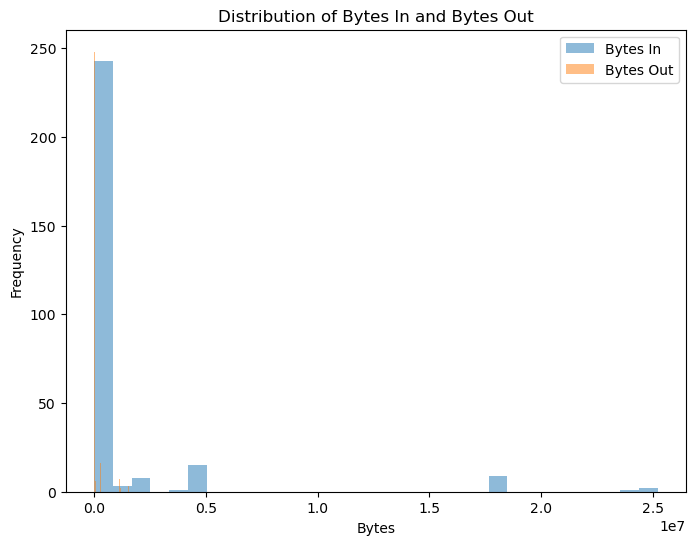

In [18]:
plt.figure(figsize=(8, 6))

plt.hist(df['bytes_in'], bins=30, alpha=0.5, label='Bytes In')
plt.hist(df['bytes_out'], bins=30, alpha=0.5, label='Bytes Out')

plt.title("Distribution of Bytes In and Bytes Out")
plt.xlabel("Bytes")
plt.ylabel("Frequency")
plt.legend()

plt.show()

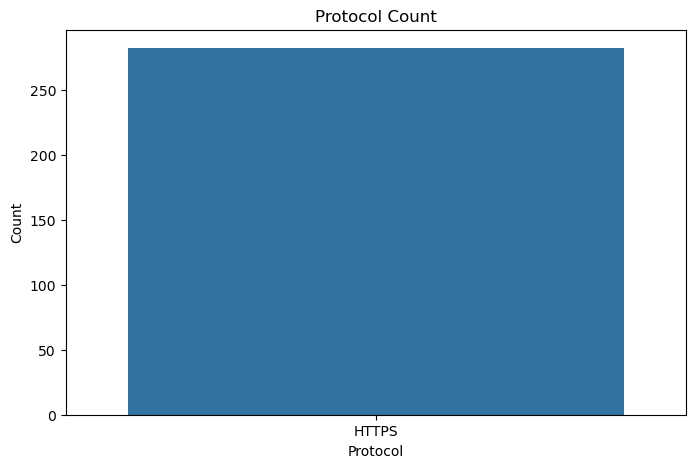

In [20]:
plt.figure(figsize=(8, 5))
sns.countplot(x='protocol', data=df, order=df['protocol'].value_counts().index)

plt.title("Protocol Count")
plt.xlabel("Protocol")
plt.ylabel("Count")

plt.show()

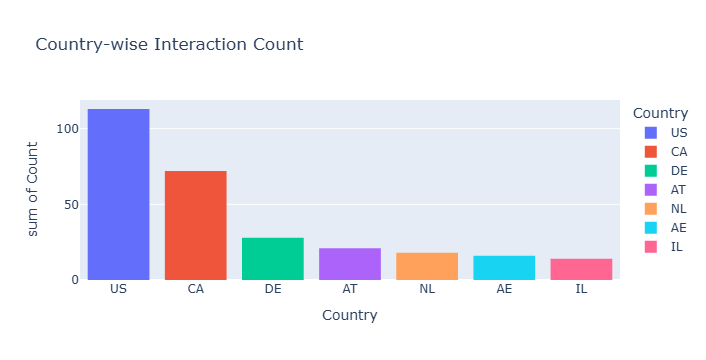

In [22]:
import plotly.express as px
# Count interactions per country
country_counts = df['src_ip_country_code'].value_counts().reset_index()
country_counts.columns = ['Country', 'Count']

# Plot the histogram
fig = px.histogram(country_counts, x='Country', y='Count', color='Country', title="Country-wise Interaction Count")
fig.show()

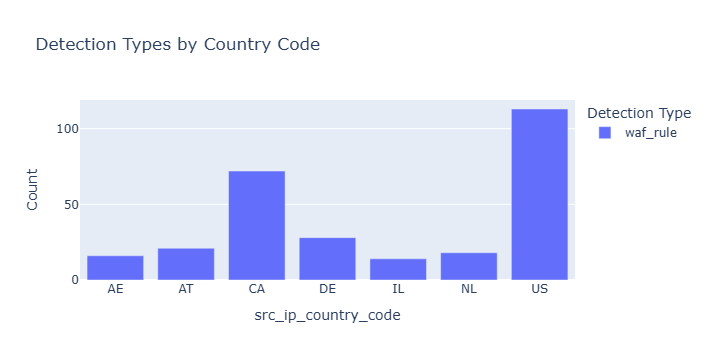

In [23]:
# Create a data frame of detection types by country
detection_types_by_country = pd.crosstab(df['src_ip_country_code'], df['detection_types']).reset_index()

# Melt the data to long format for Plotly
detection_types_long = detection_types_by_country.melt(id_vars='src_ip_country_code', var_name='Detection Type', value_name='Count')

# Plotly stacked bar chart
fig = px.bar(detection_types_long, x='src_ip_country_code', y='Count', color='Detection Type', title='Detection Types by Country Code', barmode='stack')
fig.show()

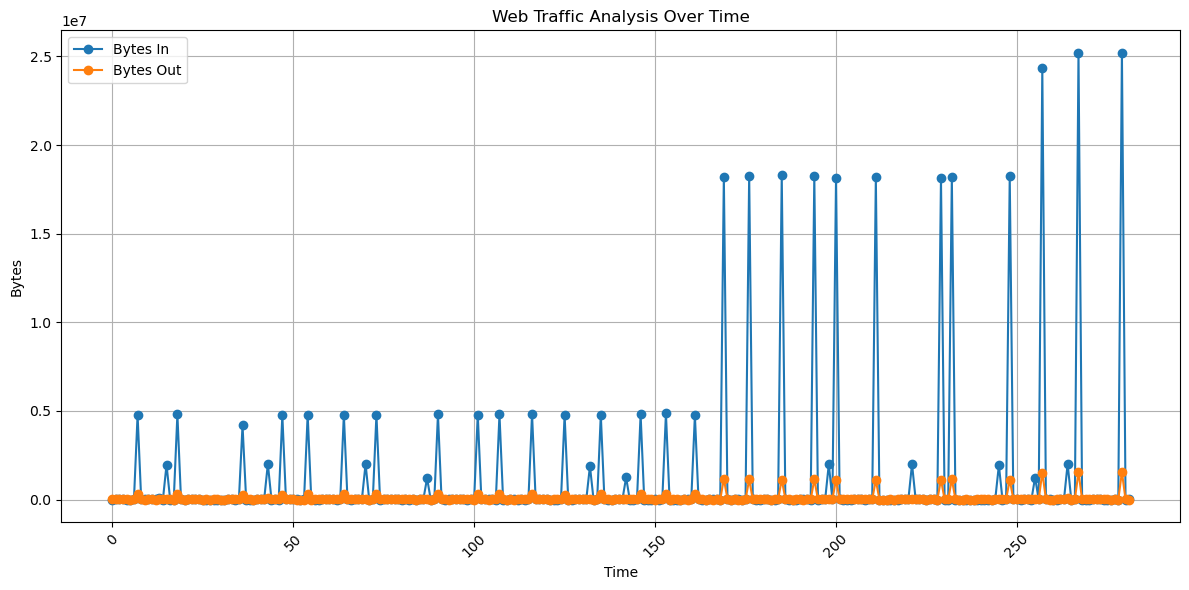

In [24]:
# Plotting
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['bytes_in'], label='Bytes In',
marker='o')
plt.plot(df.index, df['bytes_out'], label='Bytes Out',
marker='o')
plt.title('Web Traffic Analysis Over Time')
plt.xlabel('Time')
plt.ylabel('Bytes')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
# Show the plot
plt.show()

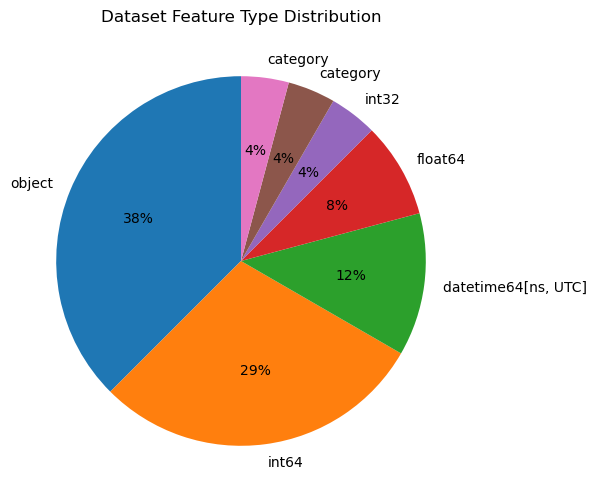

In [26]:
# Count column types
types = df.dtypes.value_counts()

plt.figure(figsize=(6,6))

plt.pie(types,
        labels=types.index.astype(str),
        autopct='%1.0f%%',
        startangle=90)

plt.title("Dataset Feature Type Distribution")

plt.show()

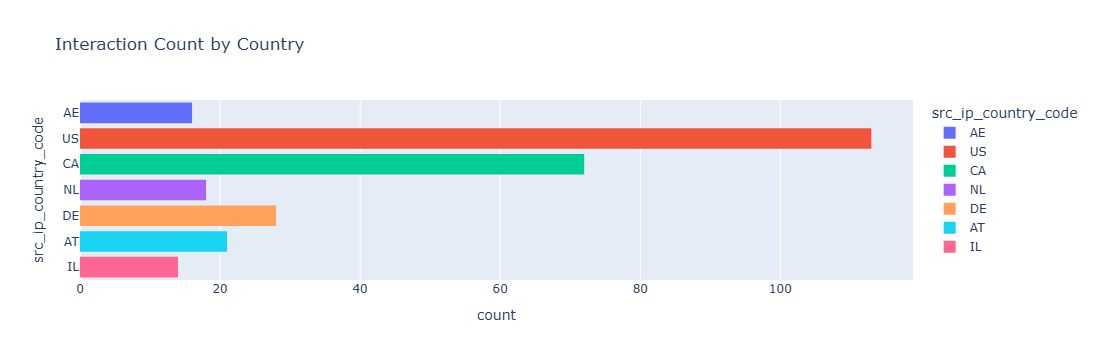

In [27]:
# Country-wise interaction
fig_country = px.histogram(df, y='src_ip_country_code', color='src_ip_country_code', title='Interaction Count by Country')
fig_country.show()

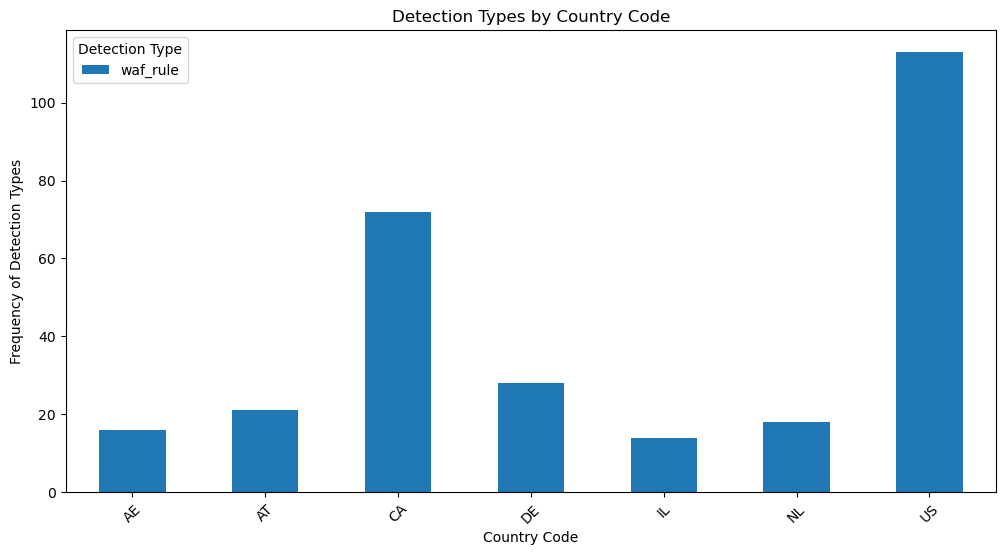

In [29]:
# Stacked Bar Chart for Detection Types by Country
# Preparing data for stacked bar chart
detection_types_by_country = pd.crosstab(transformed_df['src_ip_country_code'],
transformed_df['detection_types'])
detection_types_by_country.plot(kind='bar', stacked=True,
figsize=(12, 6))
plt.title('Detection Types by Country Code')
plt.xlabel('Country Code')
plt.ylabel('Frequency of Detection Types')
plt.xticks(rotation=45)
plt.legend(title='Detection Type')
plt.show()

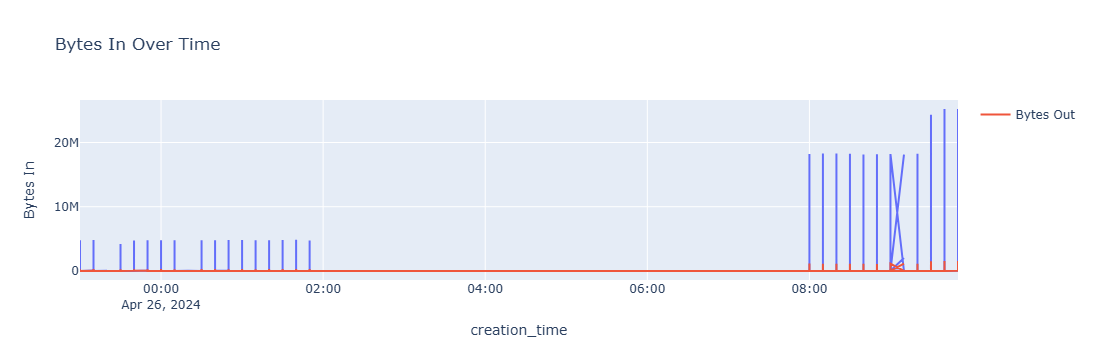

In [31]:
from sklearn.cluster import KMeans

# Reset index if 'creation_time' is the index
df = df.reset_index()

# Convert time columns to datetime objects
df['creation_time'] = pd.to_datetime(df['creation_time'])
df['end_time'] = pd.to_datetime(df['end_time'])

# Feature engineering: Session duration (must be done before setting index if column is dropped)
df['session_duration'] = (df['end_time'] - df['creation_time']).dt.total_seconds()

# Set 'creation_time' as index for time-series plotting
df.set_index('creation_time', inplace=True)

# Time-series plot of bytes in and bytes out
fig = px.line(df, x=df.index, y='bytes_in', title='Bytes In Over Time', labels={'bytes_in': 'Bytes In'})
fig.add_scatter(x=df.index, y=df['bytes_out'], mode='lines', name='Bytes Out')
fig.show()

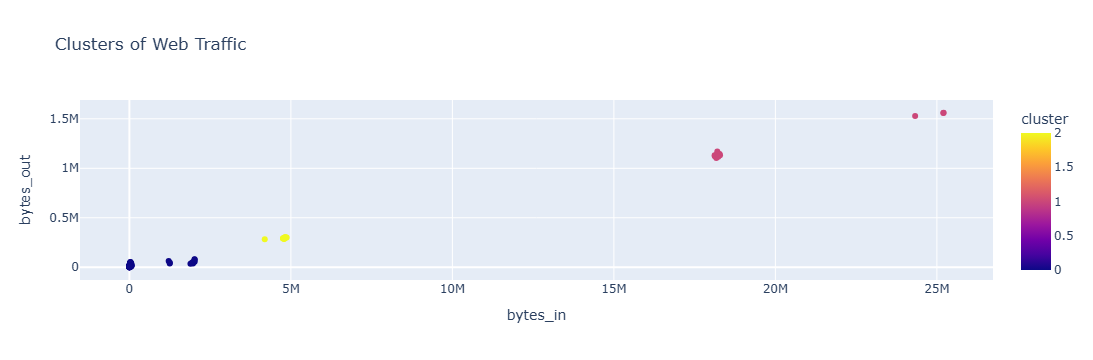

In [32]:
# Clustering with KMeans
features = df[['bytes_in', 'bytes_out', 'session_duration']]
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(features)

# Plot clusters
fig_cluster = px.scatter(df, x='bytes_in', y='bytes_out', color='cluster', title='Clusters of Web Traffic')
fig_cluster.show()

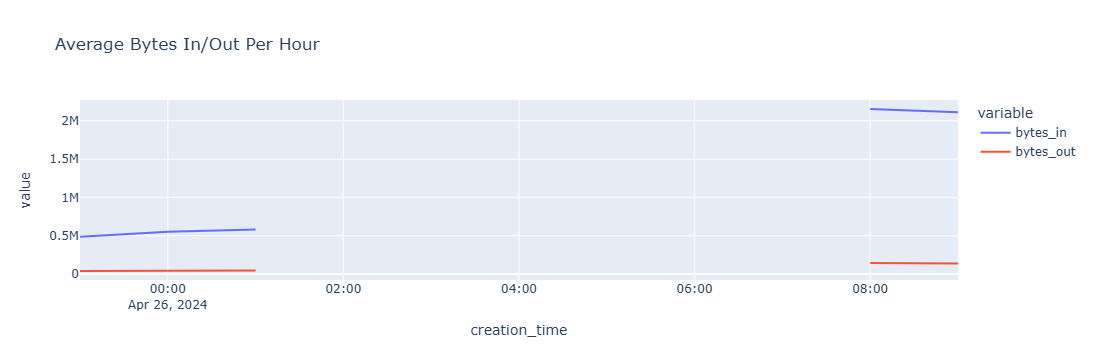

In [33]:
# Resample data by hour (or any other time period)
hourly_data = df.resample('H').agg({
    'bytes_in': 'mean',
    'bytes_out': 'mean',
    'session_duration': 'mean'  # If needed
})

# Plot the hourly aggregated data
fig_hourly = px.line(hourly_data, y=['bytes_in', 'bytes_out'], title='Average Bytes In/Out Per Hour')
fig_hourly.show()

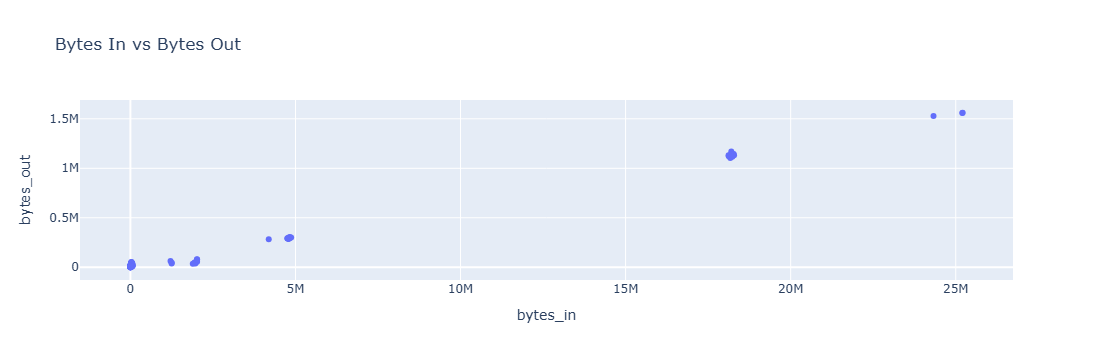

In [34]:
# Scatter plot of bytes in vs bytes out
fig_scatter = px.scatter(df, x='bytes_in', y='bytes_out', title='Bytes In vs Bytes Out')
fig_scatter.show()

In [35]:
# Create a graph
G = nx.Graph()
# Add edges from source IP to destination IP
for idx, row in df.iterrows():
    G.add_edge(row['src_ip'], row['dst_ip'])

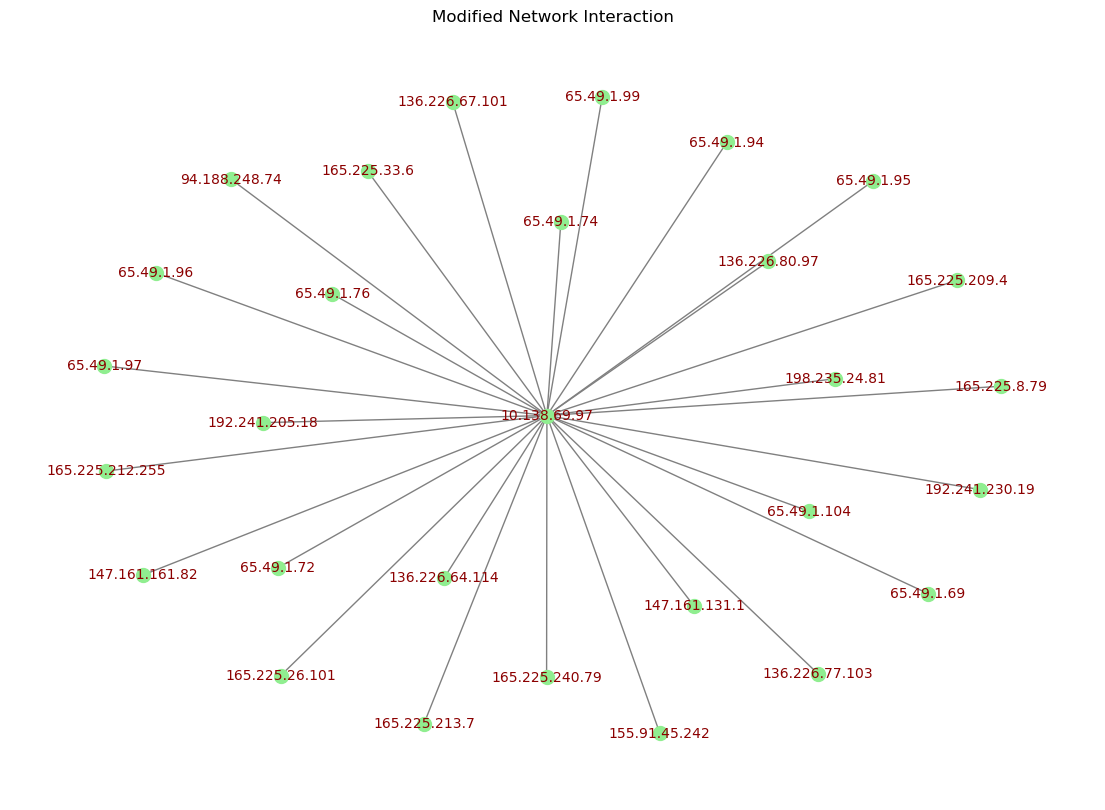

In [36]:
# Draw the network graph with modifications
plt.figure(figsize=(14, 10))
nx.draw_networkx(
    G,
    with_labels=True,
    node_size=100,         # Increase node size
    font_size=10,         # Increase label font size
    node_color='lightgreen',  # Change node color
    edge_color='gray',     # Change edge color
    font_color='darkred'  # Change font color
)
plt.title('Modified Network Interaction')
plt.axis('off')  # Turn off the axis
plt.show()

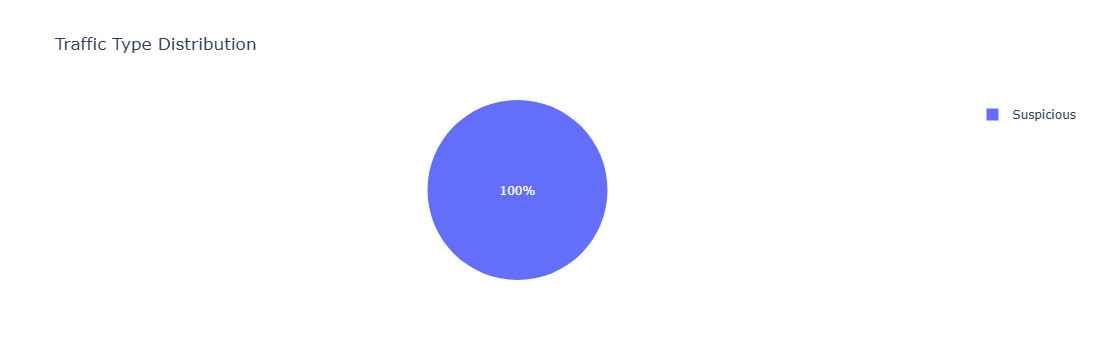

In [38]:
# First, ensure 'is_suspicious' is defined based on 'detection_types'
df['is_suspicious'] = (df['detection_types'] == 'waf_rule').astype(int)

# Count traffic types
df['traffic_type'] = df['is_suspicious'].map({0: 'Normal', 1: 'Suspicious'})
traffic_counts = df['traffic_type'].value_counts().reset_index()
traffic_counts.columns = ['Traffic Type', 'Count']

# Create a pie chart
fig = px.pie(traffic_counts, values='Count', names='Traffic Type', title='Traffic Type Distribution')
fig.show()

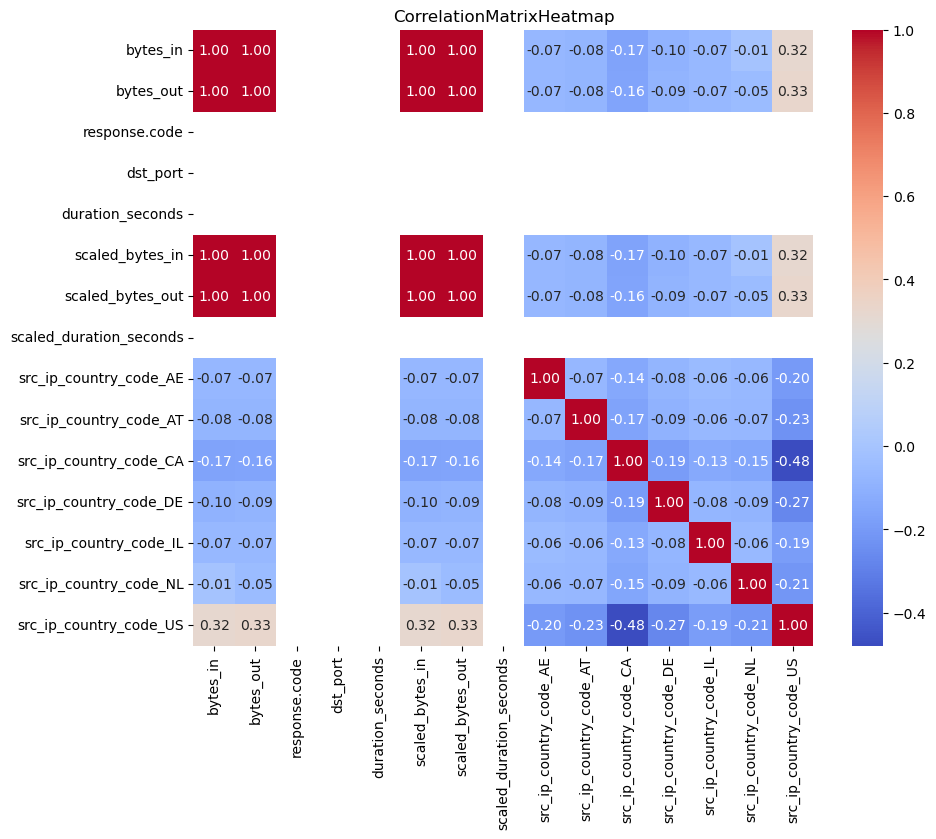

In [37]:
# Heatmap for the correlation matrix
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix_numeric,annot=True,fmt=".2f",cmap='coolwarm')
plt.title('CorrelationMatrixHeatmap')
plt.show()

## Data Visualization

#### Country-based Interaction Analysis

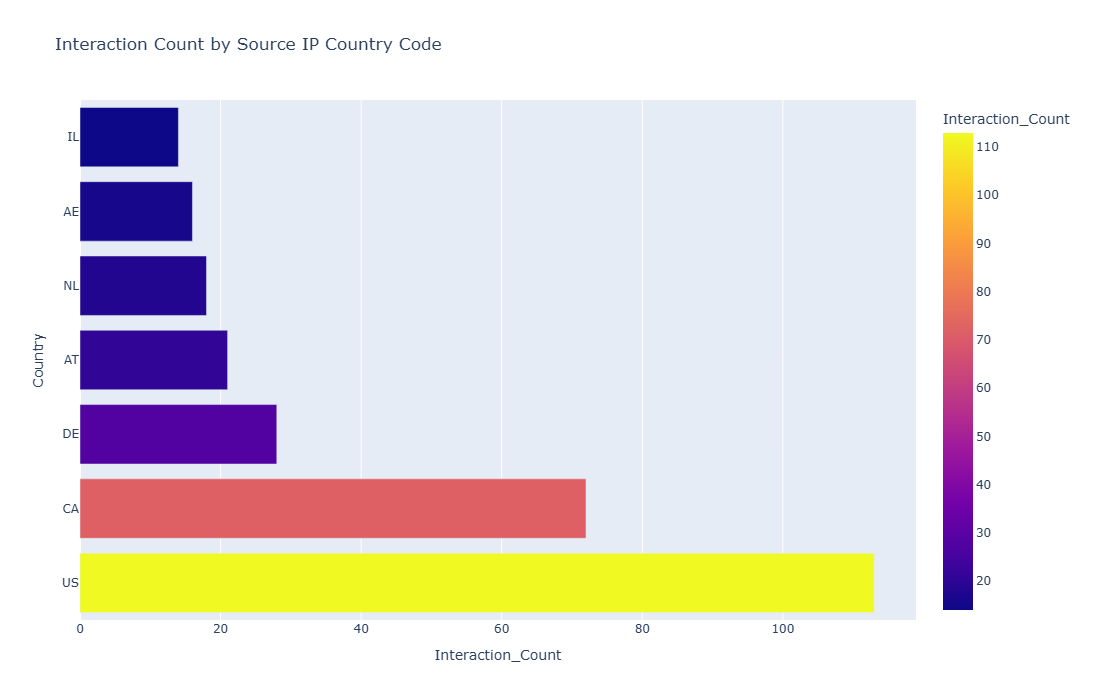

In [39]:
# Count interactions per country
country_counts = df['src_ip_country_code'].value_counts().reset_index()
country_counts.columns = ['Country', 'Interaction_Count']

# Create interactive horizontal bar chart
fig = px.bar(country_counts,
             y='Country',
             x='Interaction_Count',
             orientation='h',
             title='Interaction Count by Source IP Country Code',
             color='Interaction_Count')

fig.update_layout(width=1000, height=700)
fig.show()

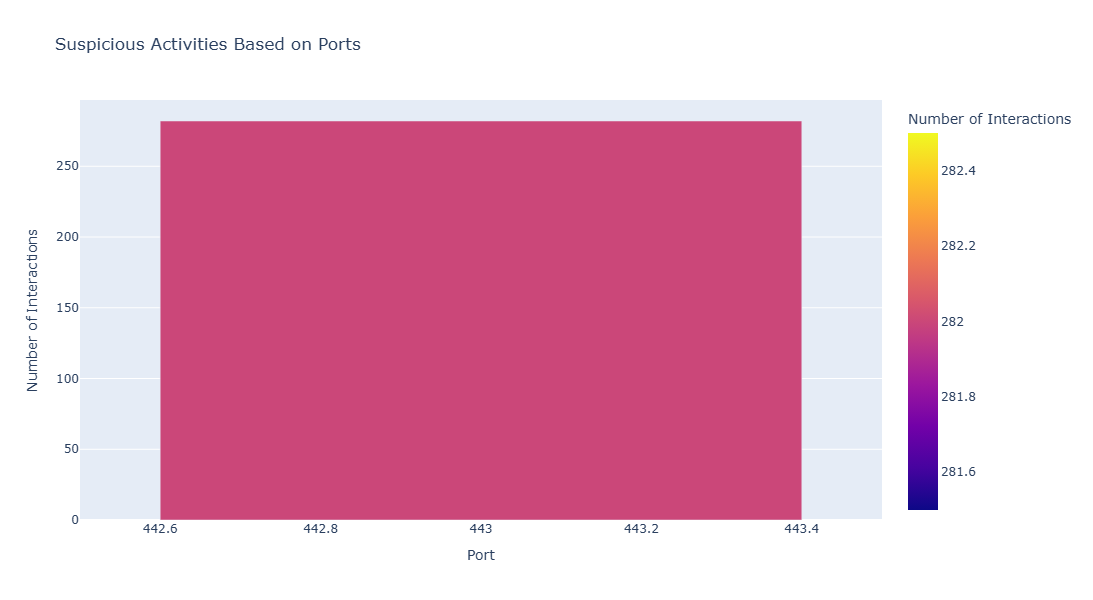

In [40]:
# Common suspicious / frequently targeted ports
suspicious_ports = [21, 22, 23, 25, 53, 80, 110, 135, 139, 143, 443, 445, 3389]

# Filter dataset for suspicious ports
suspicious_df = df[df['dst_port'].isin(suspicious_ports)]

# Count occurrences of each suspicious port
port_counts = suspicious_df['dst_port'].value_counts().reset_index()
port_counts.columns = ['Port', 'Interaction_Count']

# Plot bar chart
fig = px.bar(port_counts,
             x='Port',
             y='Interaction_Count',
             title='Suspicious Activities Based on Ports',
             labels={'Interaction_Count': 'Number of Interactions'},
             color='Interaction_Count')

fig.update_layout(width=1000, height=600)
fig.show()

## Modeling: Anomaly Detection

#### This step uses Isolation Forest, a common technique for detecting anomalies




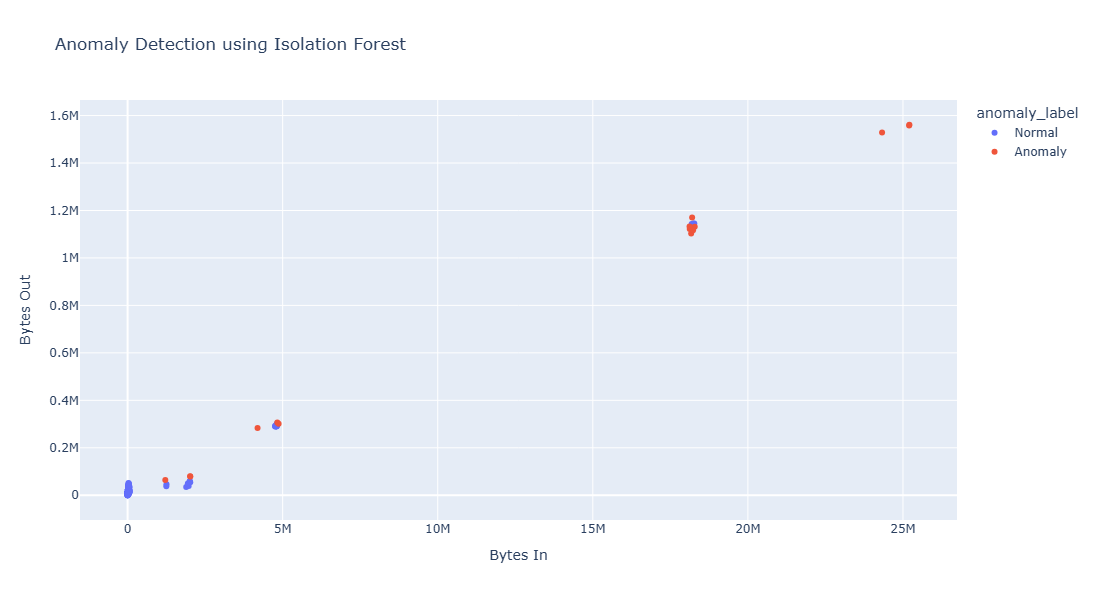

In [41]:
from sklearn.ensemble import IsolationForest

# Select numerical features for anomaly detection
features = df[['bytes_in', 'bytes_out', 'session_duration']]
#  Initialize Isolation Forest model
# contamination = expected percentage of anomalies (5% here)
iso_model = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)


#  Train the model

df['anomaly'] = iso_model.fit_predict(features)

# IsolationForest output:
# -1  → Anomaly
#  1  → Normal


#  Convert output for better visualization
df['anomaly_label'] = df['anomaly'].map({1: 'Normal', -1: 'Anomaly'})

# Visualize anomalies

fig = px.scatter(
    df,
    x='bytes_in',
    y='bytes_out',
    color='anomaly_label',
    title='Anomaly Detection using Isolation Forest',
    labels={'bytes_in': 'Bytes In', 'bytes_out': 'Bytes Out'}
)

fig.update_layout(width=1000, height=600)
fig.show()

### RandomForestClassifier

In [42]:
# First, encode this column into binary labels
transformed_df['is_suspicious'] = (transformed_df['detection_types'] == 'waf_rule').astype(int)
# Features and Labels
X = transformed_df[['bytes_in', 'bytes_out','scaled_duration_seconds']]
# Numeric features
y = transformed_df['is_suspicious'] # Binary labels
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y,
test_size=0.3, random_state=42)
# Initialize the Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100,
random_state=42)
# Train the model
rf_classifier.fit(X_train, y_train)
# Predict on the test set
y_pred = rf_classifier.predict(X_test)

## Evaluation

#### Evaluation Metrics Used:

#### Accuracy

#### Precision

#### Recall

#### F1-Score

#### Confusion Matrix

Model Accuracy: 0.9468085106382979

Classification Report:
              precision    recall  f1-score   support

          -1       0.00      0.00      0.00         0
           1       1.00      0.95      0.97       282

    accuracy                           0.95       282
   macro avg       0.50      0.47      0.49       282
weighted avg       1.00      0.95      0.97       282



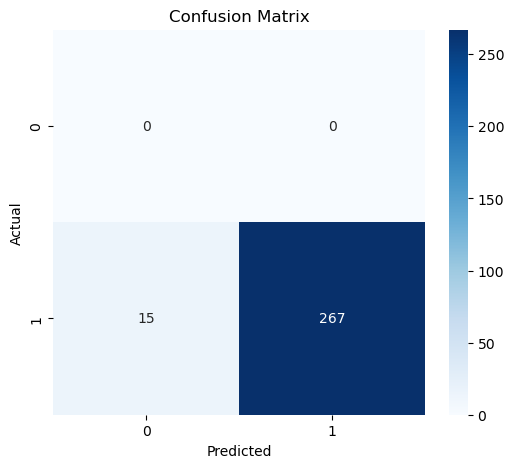

In [43]:
# Ensure 'is_suspicious' column exists for evaluation
df['is_suspicious'] = (df['detection_types'] == 'waf_rule').astype(int)

# True labels (example column)
y_true = df['is_suspicious']
y_pred = df['anomaly']        # Isolation Forest prediction

#  Accuracy
accuracy = accuracy_score(y_true, y_pred)
print("Model Accuracy:", accuracy)

#  Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred))

# Confusion Matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [44]:
# Check the proportion of anomalies detected
print(df['anomaly'].value_counts())

# Display anomaly samples (-1 means anomaly)
suspicious_activities = df[df['anomaly'] == -1]
print(suspicious_activities.head())

anomaly
 1    267
-1     15
Name: count, dtype: int64
                           index  bytes_in  bytes_out  \
creation_time                                           
2024-04-25 23:30:00+00:00     36   4190330     283456   
2024-04-25 23:40:00+00:00     43   2015975      79990   
2024-04-26 00:30:00+00:00     87   1215594      64362   
2024-04-26 01:00:00+00:00    116   4827283     306181   
2024-04-26 01:40:00+00:00    153   4869181     301752   

                                           end_time          src_ip  \
creation_time                                                         
2024-04-25 23:30:00+00:00 2024-04-25 23:40:00+00:00   155.91.45.242   
2024-04-25 23:40:00+00:00 2024-04-25 23:50:00+00:00  165.225.240.79   
2024-04-26 00:30:00+00:00 2024-04-26 00:40:00+00:00  165.225.240.79   
2024-04-26 01:00:00+00:00 2024-04-26 01:10:00+00:00   155.91.45.242   
2024-04-26 01:40:00+00:00 2024-04-26 01:50:00+00:00   155.91.45.242   

                          src_ip_country_code pr

## Visualization of Anomalies

#### 1️ Scatter Plot 
#### 2️ Distribution Plot 
#### 3️ Country-wise Anomaly Count

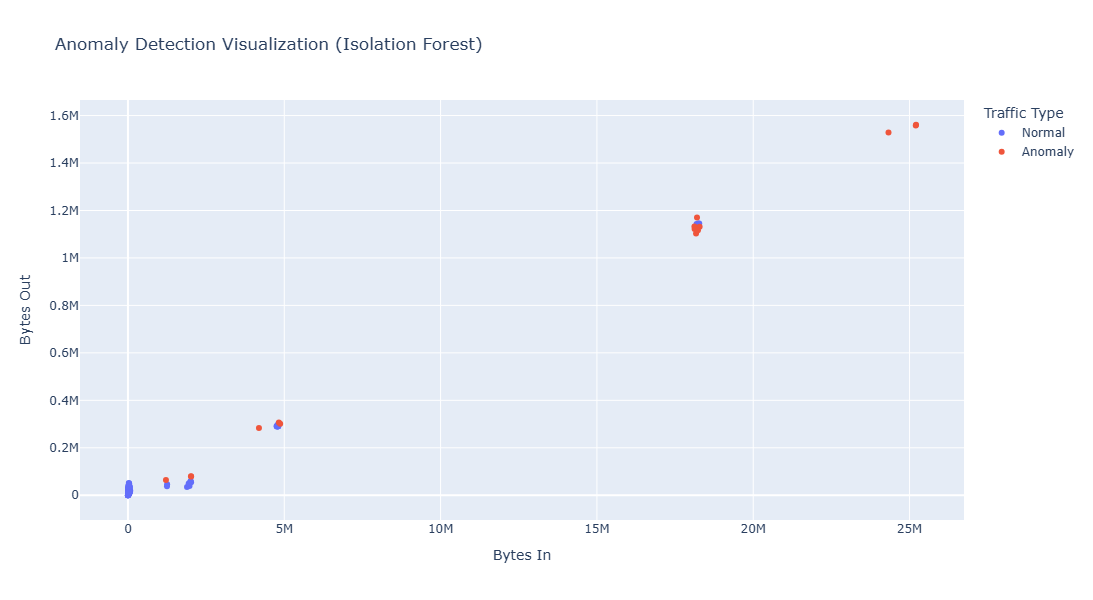

In [45]:
# Scatter plot to visualize anomalies
fig = px.scatter(
    df,
    x='bytes_in',                 # X-axis feature
    y='bytes_out',                # Y-axis feature
    color='anomaly_label',        # Color based on Normal/Anomaly
    title='Anomaly Detection Visualization (Isolation Forest)',
    labels={
        'bytes_in': 'Bytes In',
        'bytes_out': 'Bytes Out',
        'anomaly_label': 'Traffic Type'
    }
)

# Increase size for better visibility
fig.update_layout(width=1000, height=600)

fig.show()

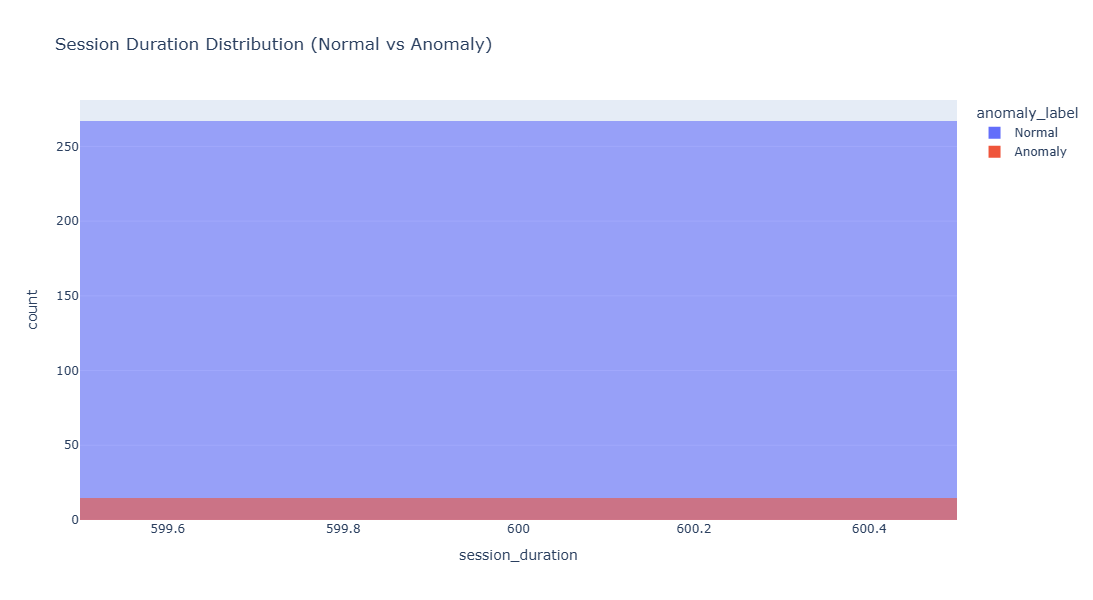

In [46]:
# Histogram to compare session duration
fig = px.histogram(
    df,
    x='session_duration',
    color='anomaly_label',
    barmode='overlay',
    title='Session Duration Distribution (Normal vs Anomaly)',
    opacity=0.6
)

fig.update_layout(width=1000, height=600)

fig.show()

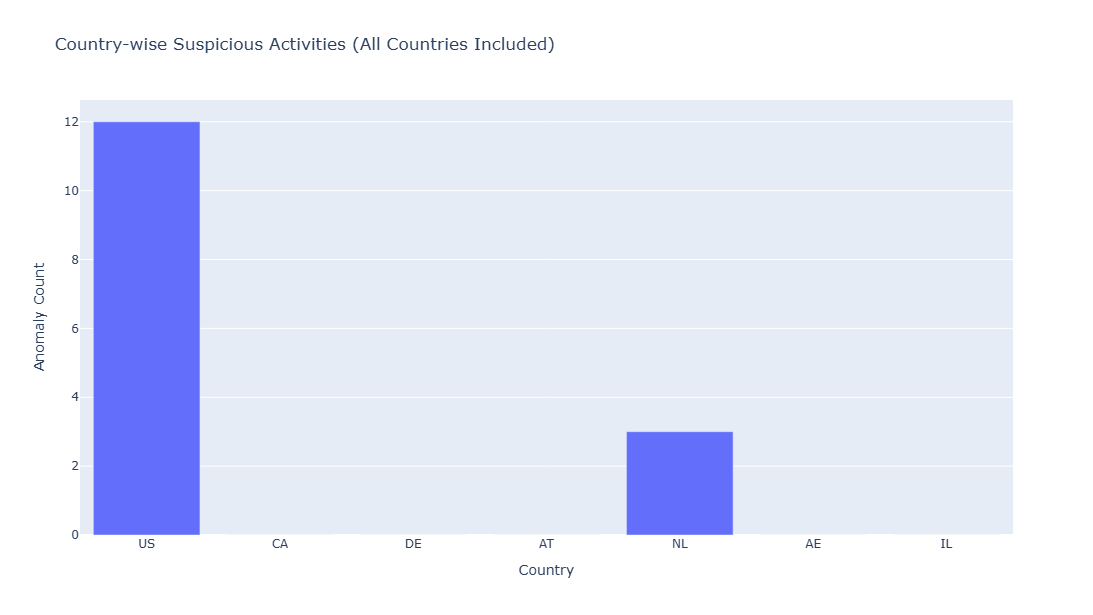

In [47]:
# Count anomalies by country
anomaly_counts = df[df['anomaly_label'] == 'Anomaly']['src_ip_country_code'].value_counts()

# Get all countries from dataset
all_countries = df['src_ip_country_code'].value_counts().index

# Reindex to include all countries (fill missing with 0)
country_anomaly = anomaly_counts.reindex(all_countries, fill_value=0).reset_index()
country_anomaly.columns = ['Country', 'Anomaly Count']

# Plot
fig = px.bar(
    country_anomaly,
    x='Country',
    y='Anomaly Count',
    title='Country-wise Suspicious Activities (All Countries Included)'
)

fig.update_layout(width=1100, height=600)

fig.show()

## Neural Network

In [48]:
df['is_suspicious'] = (df['detection_types'] =='waf_rule').astype(int)
# Features and labels
X = df[['bytes_in', 'bytes_out']].values # Using only numeric features
y = df['is_suspicious'].values
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y,
test_size=0.3, random_state=42)
# Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# Neural network model
model = Sequential([
Dense(8, activation='relu',
input_shape=(X_train_scaled.shape[1],)),
Dense(16, activation='relu'),
Dense(1, activation='sigmoid')
])
# Compile the model
model.compile(optimizer=Adam(), loss='binary_crossentropy',
metrics=['accuracy'])
# Train the model
history = model.fit(X_train_scaled, y_train, epochs=10,
batch_size=8, verbose=1)
# Evaluate the model
loss, accuracy = model.evaluate(X_test_scaled, y_test)
print(f"Test Accuracy: {accuracy*100:.2f}%")

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8985 - loss: 0.6078
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9594 - loss: 0.4917
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.3788
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.2783
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.1982
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.1407
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.1010
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0742
Epoch 9/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0562
Epoch 10/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0437
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 1.0000 - loss: 0.0416 
Test Accuracy: 100.00%


## Neural network model

In [49]:
# Neural network model
model = Sequential([Dense(128, activation='relu',input_shape=(X_train_scaled.shape[1],)),Dropout(0.5),
Dense(128, activation='relu'),Dropout(0.5),Dense(1, activation='sigmoid')])

In [50]:
# Compile the model
model.compile(optimizer=Adam(), loss='binary_crossentropy',metrics=['accuracy'])
# Train the model
history = model.fit(X_train_scaled, y_train, epochs=10,batch_size=32, verbose=1, validation_split=0.2)

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - accuracy: 0.9045 - loss: 0.6532 - val_accuracy: 1.0000 - val_loss: 0.5636
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 1.0000 - loss: 0.5734 - val_accuracy: 1.0000 - val_loss: 0.4914
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 1.0000 - loss: 0.5005 - val_accuracy: 1.0000 - val_loss: 0.4229
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 1.0000 - loss: 0.4250 - val_accuracy: 1.0000 - val_loss: 0.3523
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 1.0000 - loss: 0.3607 - val_accuracy: 1.0000 - val_loss: 0.2808
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 1.0000 - loss: 0.2845 - val_accuracy: 1.0000 - val_loss: 0.2112
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 1.0000 - loss: 0.2135 - val_accuracy: 1.0000 - val_loss: 0.1493
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 1.0000 - loss: 0.1446 - val_accuracy: 1.0000 - val_loss: 0.0999


In [51]:
# Evaluate the model
loss, accuracy = model.evaluate(X_test_scaled, y_test)
print(f"Test Accuracy: {accuracy*100:.2f}%")


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 1.0000 - loss: 0.0475
Test Accuracy: 100.00%


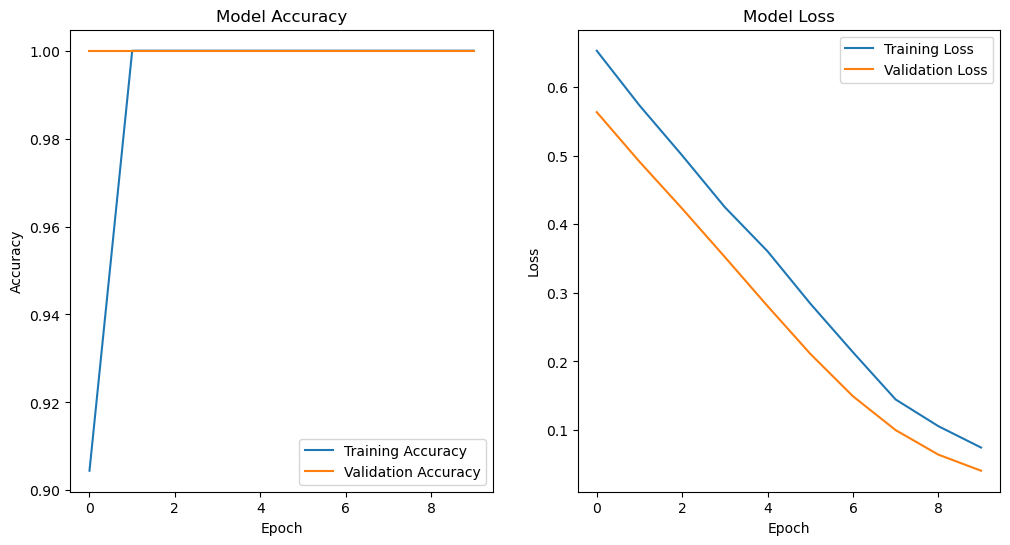

In [52]:
# Plotting the training history
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [53]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.reshape(-1,X_train.shape[-1])).reshape(X_train.shape)
X_test_scaled = scaler.transform(X_test.reshape(-1,X_test.shape[-1])).reshape(X_test.shape)


In [54]:
# Adjusting the network to accommodate the input size
model = Sequential([Conv1D(32, kernel_size=1, activation='relu',input_shape=(X_train_scaled.shape[1], 1)),Flatten(),
Dense(64, activation='relu'),Dropout(0.5),Dense(1, activation='sigmoid')])

In [55]:
# Compile the model
model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

In [56]:
# Train the model
history = model.fit(X_train_scaled, y_train, epochs=10,batch_size=32, verbose=1, validation_split=0.2)
# Evaluate the model
loss, accuracy = model.evaluate(X_test_scaled, y_test)
print(f"Test Accuracy: {accuracy*100:.2f}%")

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - accuracy: 0.8344 - loss: 0.6688 - val_accuracy: 1.0000 - val_loss: 0.6341
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9809 - loss: 0.6366 - val_accuracy: 1.0000 - val_loss: 0.5913
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9936 - loss: 0.6070 - val_accuracy: 1.0000 - val_loss: 0.5534
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 1.0000 - loss: 0.5705 - val_accuracy: 1.0000 - val_loss: 0.5172
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 1.0000 - loss: 0.5346 - val_accuracy: 1.0000 - val_loss: 0.4813
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 1.0000 - loss: 0.4967 - val_accuracy: 1.0000 - val_loss: 0.4426
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 1.0000 - loss: 0.4561 - val_accuracy: 1.0000 - val_loss: 0.4015
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 1.0000 - loss: 0.4208 - val_accuracy: 1.0000 - val_loss: 0.3584

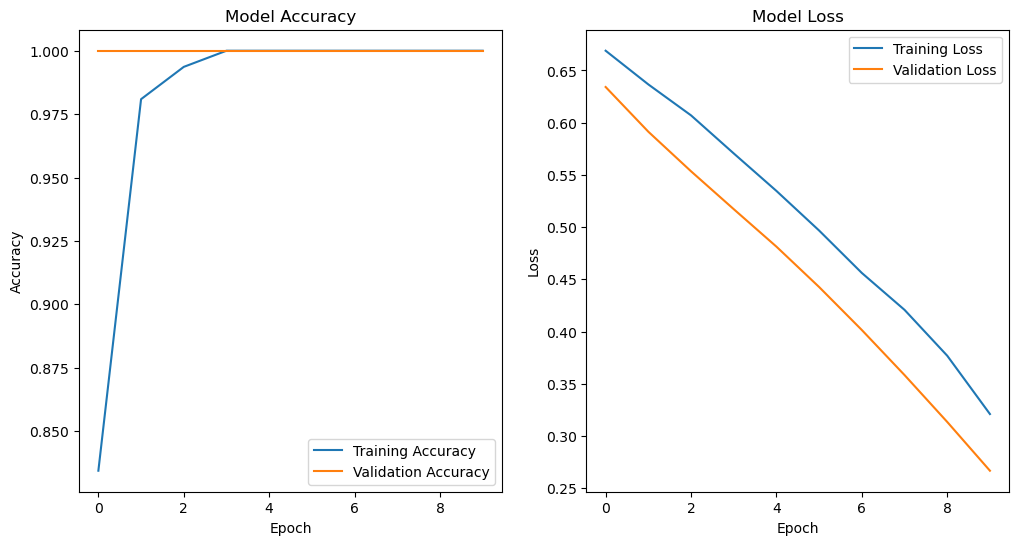

In [57]:
# Plotting the training history
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

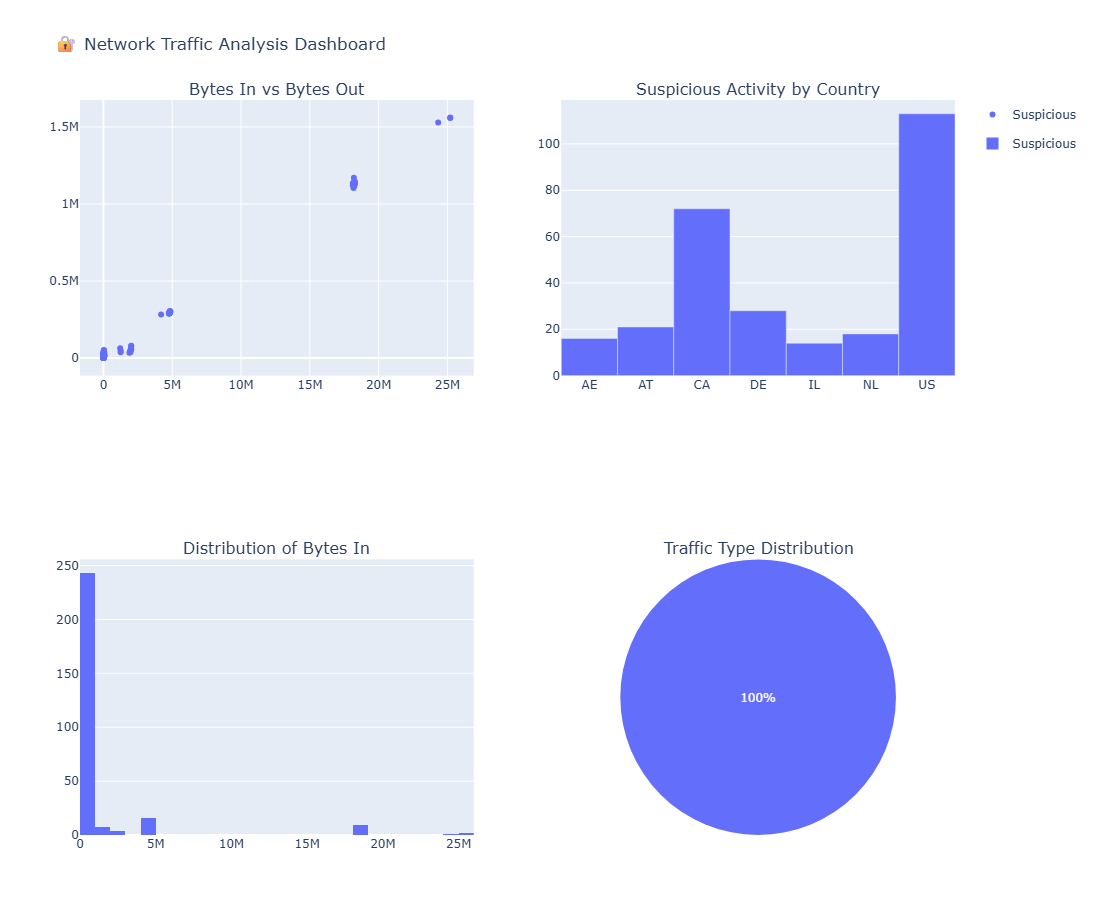

========== KPI SUMMARY ==========
Total Sessions: 282
Total Suspicious: 282
Total Normal: 0
Average Bytes In: 1199390.19
Average Bytes Out: 84554.29


In [58]:
# ===============================
# 📊 NETWORK SECURITY DASHBOARD
# (Colab + Jupyter Compatible)
# ===============================

import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.preprocessing import StandardScaler, OneHotEncoder # Required for preprocessing

# --- Data Loading and Preprocessing for transformed_df ---
# This section ensures 'transformed_df' is defined for the dashboard

# Load the dataset (from cell 3JCeS-8NeJXI)
df_raw = pd.read_csv('Downloads/CloudWatch_Traffic_Web_Attack.csv')

# Create a working copy for transformations to avoid altering original 'df' if it's used elsewhere later
df = df_raw.copy()

# Convert time-related columns to datetime format and standardize (from cell fKnvEbmze2yI)
df['creation_time'] = pd.to_datetime(df['creation_time'])
df['end_time'] = pd.to_datetime(df['end_time'])
df['time'] = pd.to_datetime(df['time'])
df['src_ip_country_code'] = df['src_ip_country_code'].str.upper()

# Feature engineering: Calculate duration of connection (from cell CBBvTxsbq-Kn)
df['duration_seconds'] = (df['end_time'] - df['creation_time']).dt.total_seconds()

# Standardize numerical features (from cell CBBvTxsbq-Kn)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[['bytes_in','bytes_out', 'duration_seconds']])

# OneHotEncoder for categorical features (from cell trfjMYeXrM_M)
encoder = OneHotEncoder(sparse_output=False)
encoded_features = encoder.fit_transform(df[['src_ip_country_code']])

# Prepare column names (from cell qd3iq5LTrkr7)
scaled_columns = ['scaled_bytes_in', 'scaled_bytes_out','scaled_duration_seconds']
encoded_columns = encoder.get_feature_names_out(['src_ip_country_code'])

# Set 'creation_time' as the index for alignment in transformed_df (similar to pApyUvP8sWfR)
df_indexed = df.set_index('creation_time')

# Convert numpy arrays back to DataFrame, aligning with df_indexed (similar to 2h_fcRhdrs4j)
scaled_df = pd.DataFrame(scaled_features, columns=scaled_columns, index=df_indexed.index)
encoded_df = pd.DataFrame(encoded_features, columns=encoded_columns, index=df_indexed.index)

# Concatenate all the data back together to create transformed_df (from cell 2h_fcRhdrs4j)
transformed_df = pd.concat([df_indexed, scaled_df, encoded_df], axis=1)

# Ensure 'is_suspicious' column exists (from cell YV1_J7Jvs-DC)
transformed_df['is_suspicious'] = (transformed_df['detection_types'] == 'waf_rule').astype(int)

# --- End of Data Loading and Preprocessing ---

# Now, `transformed_df` is fully prepared. Use it for the dashboard.
data = transformed_df.copy()

# Create anomaly label
data['traffic_type'] = data['is_suspicious'].map({0: 'Normal', 1: 'Suspicious'})

# -------------------------------
# KPI Calculations
# -------------------------------
total_sessions = len(data)
total_suspicious = data['is_suspicious'].sum()
total_normal = total_sessions - total_suspicious
avg_bytes_in = round(data['bytes_in'].mean(), 2)
avg_bytes_out = round(data['bytes_out'].mean(), 2)

# -------------------------------
# Create Subplots Layout
# -------------------------------
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "Bytes In vs Bytes Out",
        "Suspicious Activity by Country",
        "Distribution of Bytes In",
        "Traffic Type Distribution"
    ),
    specs=[[{}, {}], [{'type':'xy'}, {'type':'domain'}]] # Specify 'domain' for the pie chart
)

# -------------------------------
# 1″️⃣ Scatter Plot
# -------------------------------
scatter = px.scatter(
    data,
    x='bytes_in',
    y='bytes_out',
    color='traffic_type'
)

for trace in scatter.data:
    fig.add_trace(trace, row=1, col=1)

# -------------------------------
# 2″️⃣ Country-wise Suspicious
# -------------------------------
country_counts = data.groupby('src_ip_country_code')['is_suspicious'].sum().reset_index()

bar = px.bar(
    country_counts,
    x='src_ip_country_code',
    y='is_suspicious'
)

for trace in bar.data:
    fig.add_trace(trace, row=1, col=2)

# -------------------------------
# 3″️⃣ Histogram
# -------------------------------
hist = px.histogram(data, x='bytes_in')

for trace in hist.data:
    fig.add_trace(trace, row=2, col=1)

# -------------------------------
# 4″️⃣ Pie Chart
# -------------------------------
pie = px.pie(
    data,
    names='traffic_type'
)

for trace in pie.data:
    fig.add_trace(trace, row=2, col=2)

# -------------------------------
# Layout Settings
# -------------------------------
fig.update_layout(
    height=900,
    width=1200,
    title_text="🔐 Network Traffic Analysis Dashboard",
    showlegend=True
)

fig.show()

# -------------------------------
# Print KPIs
# -------------------------------
print("========== KPI SUMMARY ==========")
print(f"Total Sessions: {total_sessions}")
print(f"Total Suspicious: {total_suspicious}")
print(f"Total Normal: {total_normal}")
print(f"Average Bytes In: {avg_bytes_in}")
print(f"Average Bytes Out: {avg_bytes_out}")